# Welcome to SAiDL CTE 2026!!
#ML101
---

Imports


In [4]:
# Library for math
import numpy as np

# Libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.datasets import fetch_california_housing
# Library for ML/DL
import torch

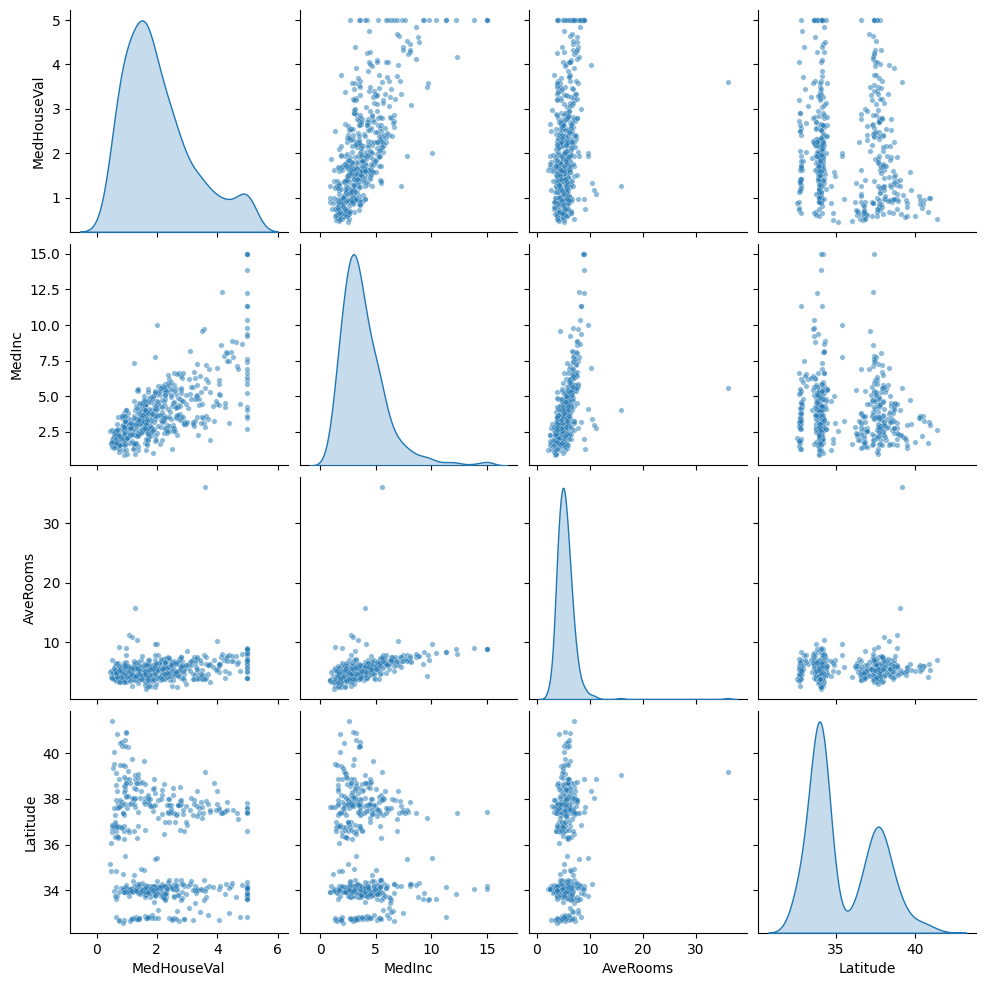

In [5]:
# Load dataset and select the top 4 features most correlated with the target
california = fetch_california_housing(as_frame=True)
df = california.frame
top_features = (
    df.corr()['MedHouseVal'].abs().sort_values(ascending=False).head(4).index
)

# Sample rows for faster rendering
df_subset = df[top_features].sample(n=500, random_state=42)

# Generate the pairplot
sns.pairplot(df_subset, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
plt.show()

## Code along: map

/tmp/ipykernel_1545/3727324483.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


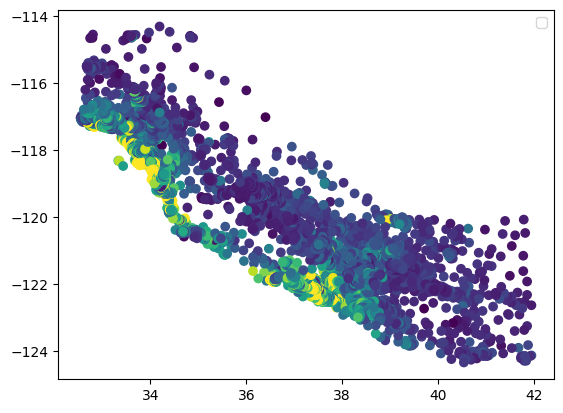

In [6]:
# Plot the map
plt.scatter(df["Latitude"], df["Longitude"], c=df["MedHouseVal"], cmap='viridis')
plt.legend()

## Plotting the cost surface

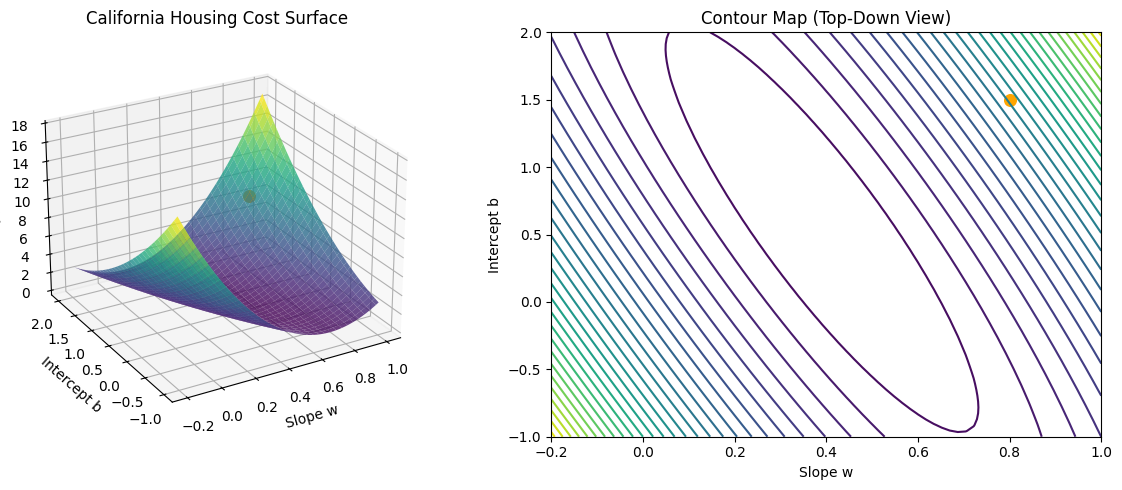

In [14]:
# 1. Isolate a single feature and target from the subset
x_data = df_subset['MedInc'].values
y_data = df_subset['MedHouseVal'].values

# 2. TODO: Define the MSE cost function for the new data

def cali_cost(slope, intercept):
    residuals = slope * x_data + intercept - y_data
    return np.mean(residuals ** 2)



# 3. Define parameter grids centered roughly around the optimal fit
# (For MedInc vs MedHouseVal, optimal w is ~0.4, b is ~0.45)
slope_values = np.linspace(-0.2, 1.0, 70)
intercept_values = np.linspace(-1.0, 2.0, 70)
slope_mesh, intercept_mesh = np.meshgrid(slope_values, intercept_values)

# 4. Compute the cost surface
cost_surface = np.array([[cali_cost(slope, intercept) for slope in slope_values] for intercept in intercept_values])

# Define a suboptimal guess to plot on the surface
guess_slope = 0.8
guess_intercept = 1.5

# 5. Plotting
figure = plt.figure(figsize=(12, 5))
surface_axis = figure.add_subplot(1, 2, 1, projection="3d")
contour_axis = figure.add_subplot(1, 2, 2)

# 3D Surface
surface_axis.plot_surface(slope_mesh, intercept_mesh, cost_surface, cmap="viridis", alpha=0.8, linewidth=0)
surface_axis.scatter([guess_slope], [guess_intercept], [cali_cost(guess_slope, guess_intercept)], color="darkorange", s=70)
surface_axis.set(xlabel="Slope w", ylabel="Intercept b", zlabel="Cost J", title="California Housing Cost Surface")
surface_axis.view_init(elev=25, azim=-120)

# 2D Contour
# Increased levels to 30 to better show the elliptical bowl shape
contour_axis.contour(slope_mesh, intercept_mesh, cost_surface, levels=30, cmap="viridis")
contour_axis.scatter([guess_slope], [guess_intercept], color="orange", s=70)
contour_axis.set(xlabel="Slope w", ylabel="Intercept b", title="Contour Map (Top-Down View)")

figure.tight_layout()
plt.show()

### Code along: Implement closed form of linear regression

In [8]:
# We will predict Median House Value using Median Income
df = df.sample(500)
x= df['MedInc'].values
y= df["MedHouseVal"].values

x_mean, y_mean = x.mean(), y.mean()
num = ((x-x_mean)*(y - y_mean)).sum()
denom = np.sum((x- x_mean) ** 2 )
w = num / denom
b = y_mean - w * x_mean
print(w, b)

0.37569255904572624 0.6285147352268596


In [9]:
len(y)

500

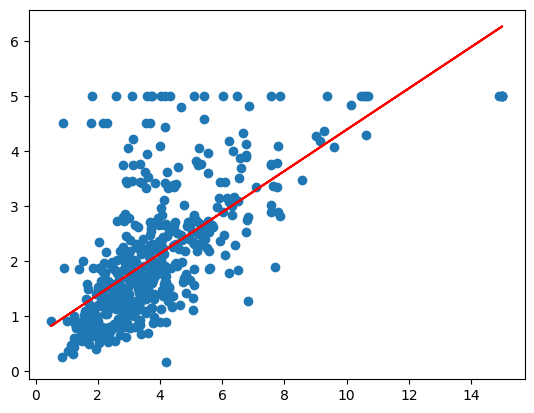

In [10]:
plt.scatter(df["MedInc"], df["MedHouseVal"])
plt.plot(x, w * x + b, 'r')
plt.show()

In [11]:
print(w * 10 + b)

4.385440325684122


## What are partial derivatives?

In [15]:
# 1. Define the multivariable function z = f(x, y)
def f(x, y):
    return x**2 + y**2

# Generate grid for the 3D surface
x = np.linspace(-3, 3, 50)
y = np.linspace(-3, 3, 50)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# 2. Pick a point of interest (x0, y0)
x0, y0 = 1.0, 1.0
z0 = f(x0, y0)

# 3. The Partial Derivative: ∂z/∂x
# TODO:
slope_x = 2*x0

# 4. Generate the "slice" curve (Intersection of surface and plane y = 1)
x_slice = np.linspace(-3, 3, 100)
y_slice = np.full_like(x_slice, y0)
z_slice = f(x_slice, y_slice)

# 5. Generate the tangent line representing the partial derivative
t = np.linspace(-1.5, 1.5, 20)
x_tan = x0 + t
y_tan = np.full_like(t, y0)
z_tan = z0 + slope_x * t

# --- Build the Plotly Figure ---
fig = go.Figure()

# Add the 3D surface
fig.add_trace(go.Surface(
    x=X, y=Y, z=Z,
    colorscale='Viridis',
    opacity=0.6,
    name='f(x, y) = x² + y²',
    showscale=False
))

# Add the curve along the surface where y is held constant
fig.add_trace(go.Scatter3d(
    x=x_slice, y=y_slice, z=z_slice,
    mode='lines',
    line=dict(color='black', width=6),
    name='Slice at y=1'
))

# Add the tangent line (the geometric meaning of the partial derivative)
fig.add_trace(go.Scatter3d(
    x=x_tan, y=y_tan, z=z_tan,
    mode='lines',
    line=dict(color='red', width=8),
    name=f'Tangent Line (Slope = {slope_x})'
))

# Add the specific point of interest
fig.add_trace(go.Scatter3d(
    x=[x0], y=[y0], z=[z0],
    mode='markers',
    marker=dict(color='red', size=8, symbol='circle'),
    name='Point (1, 1, 2)'
))

# Update layout for a better viewing angle
fig.update_layout(
    height=800,
    title='Geometric Meaning of a Partial Derivative (∂f/∂x)',
    scene=dict(
        xaxis_title='X axis',
        yaxis_title='Y axis (held constant)',
        zaxis_title='Z axis',
        camera=dict(
            eye=dict(x=1.5, y=-1.5, z=0.2) # Adjusted viewing angle
        )
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

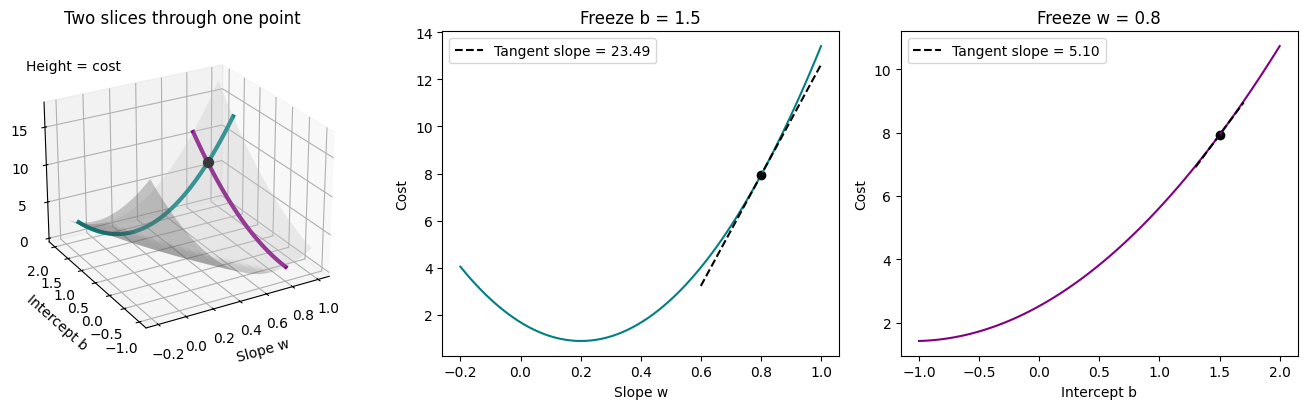

In [17]:
# Re-define the grid and probe points to match the California Housing scale
probe_slope = 0.8
probe_intercept = 1.5
small_step = 1e-5

slope_values = np.linspace(-0.2, 1.0, 70)
intercept_values = np.linspace(-1.0, 2.0, 70)
slope_mesh, intercept_mesh = np.meshgrid(slope_values, intercept_values)

# Calculate the full surface using cali_cost
cost_surface = np.array([[cali_cost(slope, intercept) for slope in slope_values] for intercept in intercept_values])

# Slice the surface along the w and b axes
slope_slice = np.array([cali_cost(value, probe_intercept) for value in slope_values])
intercept_slice = np.array([cali_cost(probe_slope, value) for value in intercept_values])

# TODO: Numeric approximation of the partial derivatives
slope_derivative_numeric = (cali_cost(probe_slope + small_step, probe_intercept) - cali_cost(probe_slope - small_step, probe_intercept)) / (2 * small_step)
intercept_derivative_numeric = (cali_cost(probe_slope, probe_intercept + small_step) - cali_cost(probe_slope, probe_intercept - small_step)) / (2 * small_step)

probe_cost = cali_cost(probe_slope, probe_intercept)

figure = plt.figure(figsize=(14, 4.2))
surface_axis = figure.add_subplot(1, 3, 1, projection="3d")
slope_axis = figure.add_subplot(1, 3, 2)
intercept_axis = figure.add_subplot(1, 3, 3)

# 3D Plot
surface_axis.plot_surface(slope_mesh, intercept_mesh, cost_surface, color="lightgray", alpha=0.3, linewidth=0)
surface_axis.plot(slope_values, np.full_like(slope_values, probe_intercept), slope_slice, color="teal", linewidth=3)
surface_axis.plot(np.full_like(intercept_values, probe_slope), intercept_values, intercept_slice, color="purple", linewidth=3)
surface_axis.scatter([probe_slope], [probe_intercept], [probe_cost], color="black", s=50)
surface_axis.set(xlabel="Slope w", ylabel="Intercept b", zlabel="", title="Two slices through one point")
surface_axis.text2D(0.02, 0.88, "Height = cost", transform=surface_axis.transAxes)
surface_axis.view_init(elev=25, azim=-120)

# 2D Cross-Section Plots
for axis, values, losses, location, derivative, color, label, frozen in [
    (slope_axis, slope_values, slope_slice, probe_slope, slope_derivative_numeric, "teal", "Slope w", f"Freeze b = {probe_intercept:g}"),
    (intercept_axis, intercept_values, intercept_slice, probe_intercept, intercept_derivative_numeric, "purple", "Intercept b", f"Freeze w = {probe_slope:g}"),
]:
    # Scaled down the tangent line length (0.2 instead of 0.5) to fit the California dataset ranges
    tangent_inputs = np.linspace(location - 0.2, location + 0.2, 40)
    axis.plot(values, losses, color=color)
    axis.plot(tangent_inputs, probe_cost + derivative * (tangent_inputs - location), "--", color="black", label=f"Tangent slope = {derivative:.2f}")
    axis.scatter([location], [probe_cost], color="black")
    axis.set(xlabel=label, ylabel="Cost", title=frozen)
    axis.legend(fontsize=10)

figure.tight_layout(rect=(0.04, 0, 1, 1))
plt.show()

## Code along: Multiple regression

In [18]:
# Extract features and target directly from your subset
X_data = df_subset[['MedInc', 'AveRooms']].values
y_data = df_subset['MedHouseVal'].values

# Add the bias column of ones to the feature matrix
X_b = np.c_[np.ones((len(X_data), 1)), X_data]

# TODO: Find best theta
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_data
print(theta_best)

# Calculate dynamic bounds for the meshgrid based on the actual data
x_min, x_max = X_data[:, 0].min(), X_data[:, 0].max()
y_min, y_max = X_data[:, 1].min(), X_data[:, 1].max()

# Generate the coordinate grid
x_surf, y_surf = np.meshgrid(np.linspace(x_min, x_max, 10), np.linspace(y_min, y_max, 10))

# Compute the predicted plane's Z values
z_surf = theta_best[0] + theta_best[1]*x_surf + theta_best[2]*y_surf

# Plotting the geometric plane and observed points
fig = go.Figure(data=[
    go.Scatter3d(
        x=X_data[:, 0],
        y=X_data[:, 1],
        z=y_data,
        mode='markers',
        name='Observed Data',
        marker=dict(size=4, opacity=0.7, color='blue')
    ),
    go.Surface(
        x=x_surf,
        y=y_surf,
        z=z_surf,
        opacity=0.6,
        name='Prediction Plane',
        colorscale='Viridis'
    )
])

fig.update_layout(
    title="Predicting House Value from Income and Rooms",
    scene=dict(
        xaxis_title='Median Income (MedInc)',
        yaxis_title='Average Rooms (AveRooms)',
        zaxis_title='Median House Value (MedHouseVal)'
    ),
    height=800
)

fig.show()

[ 0.70167418  0.40964238 -0.04233576]


## Introducing Pytorch and Optimizers

## Pytorch playground

In [19]:
import torch
import torch.optim as optim
import torch.nn as nn

## Logistic Regressiona and optimization using `torch.optim`

In [20]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

cancer_data = load_breast_cancer()
X_raw = cancer_data.data[:, 0].reshape(-1, 1) # Feature 0: Mean Radius
y_raw = cancer_data.target                    # 0 = Malignant, 1 = Benign

# Standardize the single feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_raw, dtype=torch.float32).view(-1, 1)

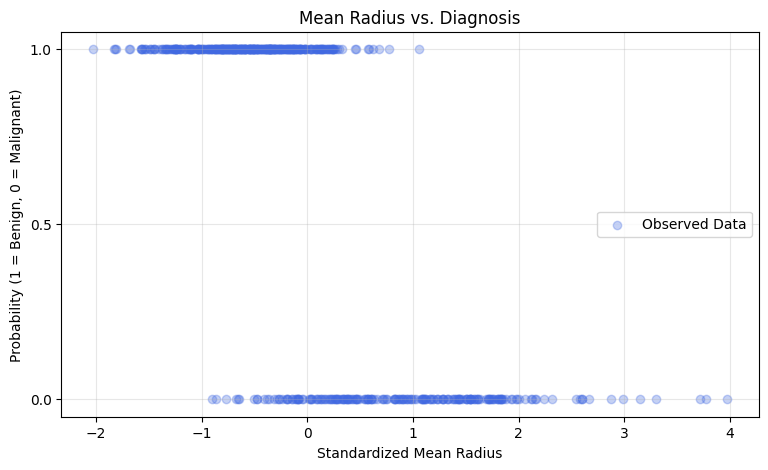

In [21]:
plt.figure(figsize=(9, 5))
plt.scatter(X_scaled, y_raw, color='royalblue', alpha=0.3, label='Observed Data')

plt.title("Mean Radius vs. Diagnosis")
plt.xlabel("Standardized Mean Radius")
plt.ylabel("Probability (1 = Benign, 0 = Malignant)")
plt.yticks([0.0, 0.5, 1.0])
plt.legend(loc="center right")
plt.grid(alpha=0.3)
plt.show()

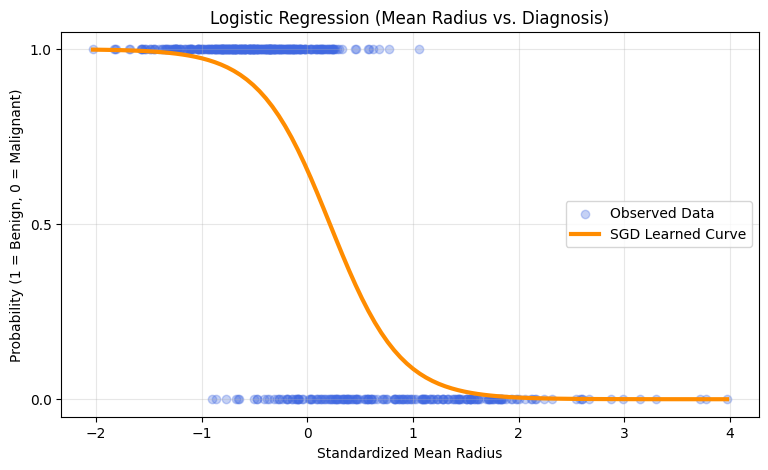

In [22]:
# Input size is 1 because we only have 1 feature
model = nn.Sequential(
    nn.Linear(in_features=1, out_features=1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
# Using SGD with a slightly higher learning rate to compensate for lack of momentum
optimizer = optim.SGD(model.parameters(), lr=0.5)

# 3. Training Loop
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model(X_tensor)
    loss = criterion(predictions, y_tensor)
    loss.backward()
    optimizer.step()

# 4. Generate the learned Sigmoid curve for plotting
# Create a smooth sequence of numbers spanning our data range
x_plot = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1, 1)
x_plot_tensor = torch.tensor(x_plot, dtype=torch.float32)

# Pass the sequence through the model without tracking gradients
with torch.no_grad():
    y_plot = model(x_plot_tensor).numpy()

# 5. Visualizing the Data and the Fit
plt.figure(figsize=(9, 5))
plt.scatter(X_scaled, y_raw, color='royalblue', alpha=0.3, label='Observed Data')
plt.plot(x_plot, y_plot, color='darkorange', linewidth=3, label='SGD Learned Curve')

plt.title("Logistic Regression (Mean Radius vs. Diagnosis)")
plt.xlabel("Standardized Mean Radius")
plt.ylabel("Probability (1 = Benign, 0 = Malignant)")
plt.yticks([0.0, 0.5, 1.0])
plt.legend(loc="center right")
plt.grid(alpha=0.3)
plt.show()